In [1]:
import numpy as np

from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

from monitorch.visualizer import PlayerVisualizer, MatplotlibVisualizer

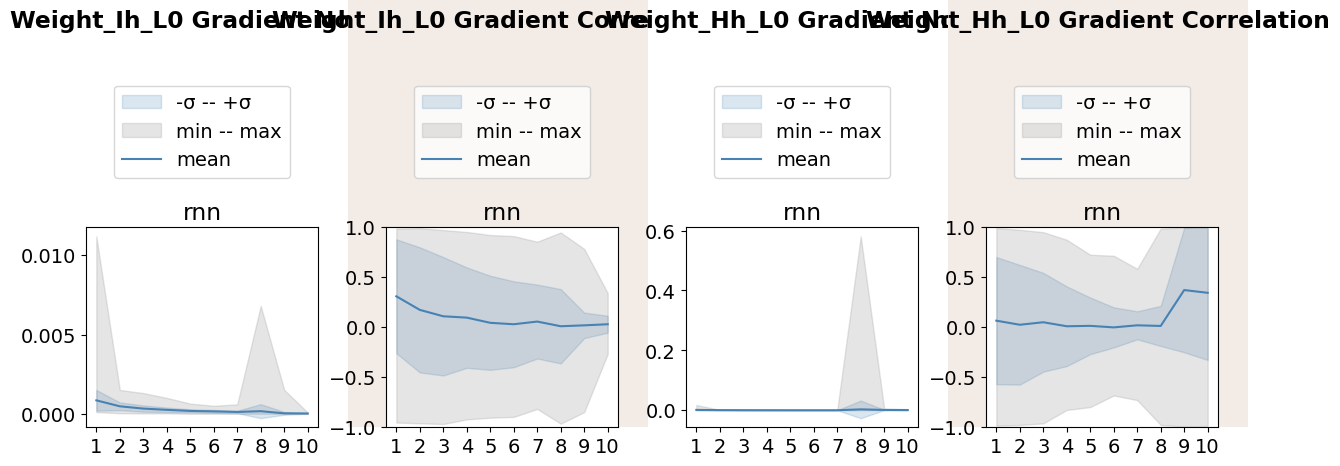

In [2]:
file = 'logs/large_rnn_long_seq.pkl'

player = PlayerVisualizer(file, MatplotlibVisualizer()).playback()
fig = player.visualizer.show_fig()
bad_to_plot = player.visualizer._to_plot

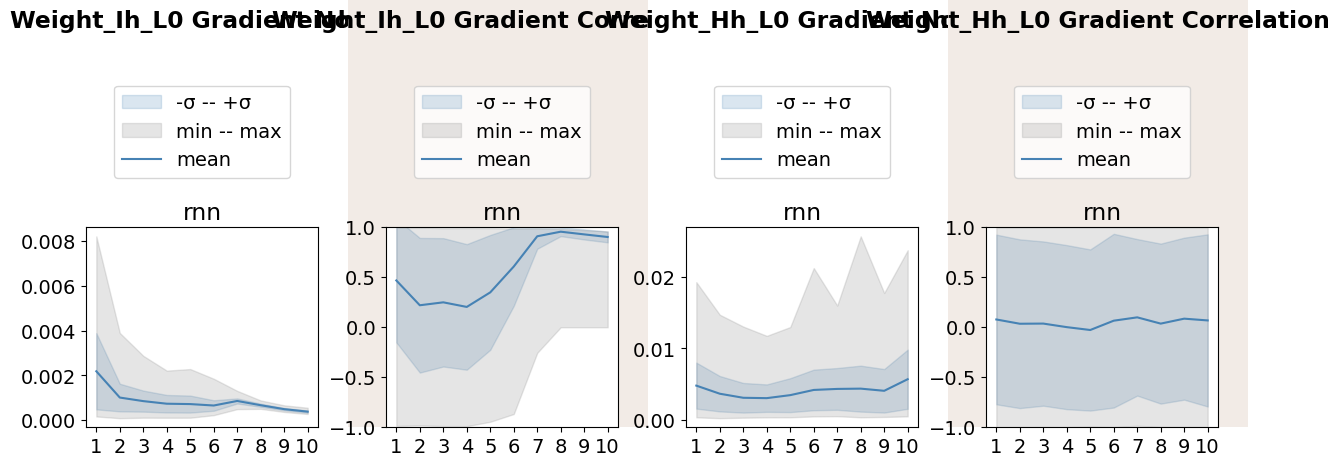

In [3]:
file = 'logs/logs.pkl'

player = PlayerVisualizer(file, MatplotlibVisualizer()).playback()
fig = player.visualizer.show_fig()
good_to_plot = player.visualizer._to_plot

In [4]:
bad_to_plot['Weight_Ih_L0 Gradient Norm']['rnn']

({'mean': OrderedDict([(1, 0.000864274186186957),
               (2, 0.0004907222387788349),
               (3, 0.0003459820797608703),
               (4, 0.0002673503166879528),
               (5, 0.00020018266721745026),
               (6, 0.0001708287824410947),
               (7, 0.0001343976530304644),
               (8, 0.00018341058370424445),
               (9, 4.734963649680142e-05),
               (10, 3.8505521870683886e-05)])},
 {('-σ',
   '+σ'): (OrderedDict([(1, 0.00021244341908732147),
                (2, 0.00024611446252362944),
                (3, 0.00014823036015962314),
                (4, 0.00012542727880824635),
                (5, 0.00010093546206397971),
                (6, 7.855335676380454e-05),
                (7, 5.93077454877902e-05),
                (8, -0.00025807061089582053),
                (9, -4.057292540632691e-05),
                (10, 2.265788391181362e-05)]), OrderedDict([(1,
                 0.0015161049532865923),
                (2, 0.000735330

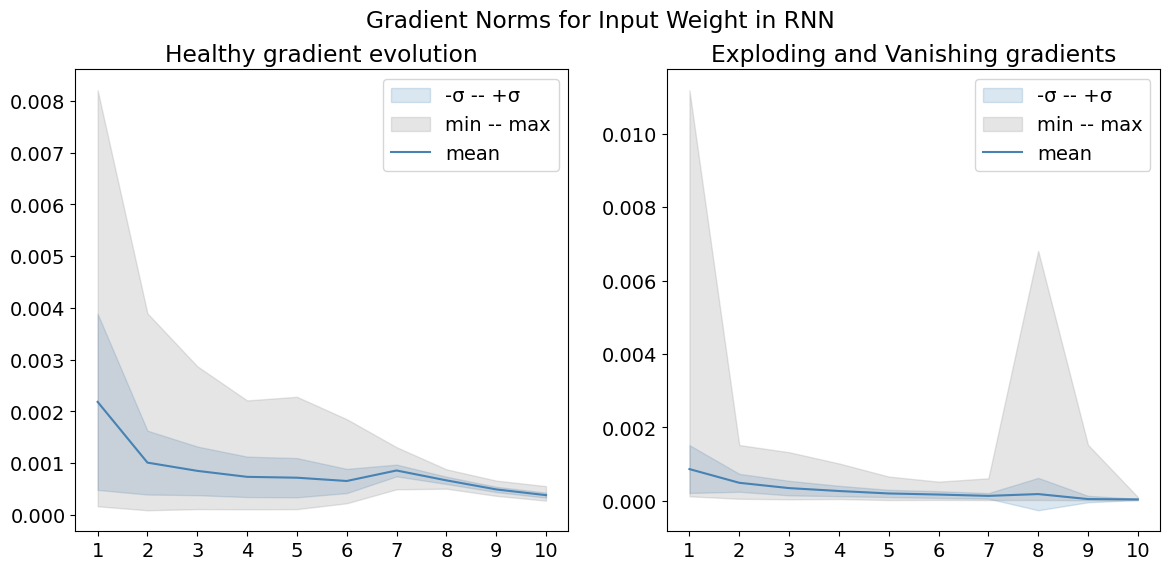

In [5]:
fig, [ax1, ax2] = plt.subplots(ncols=2, figsize=(14,6))
fig.suptitle('Gradient Norms for Input Weight in RNN')

ax1.set_title('Healthy gradient evolution')
vals, ranges = good_to_plot['Weight_Ih_L0 Gradient Norm']['rnn']
MatplotlibVisualizer._plot_numerical(ax1, vals, ranges)
ax1.legend()

ax2.set_title('Exploding and Vanishing gradients')
vals, ranges = bad_to_plot['Weight_Ih_L0 Gradient Norm']['rnn']
MatplotlibVisualizer._plot_numerical(ax2, vals, ranges)
ax2.legend()

fig.savefig('figs/gradient_norm_comparison.pdf')

# Gradient Correlation

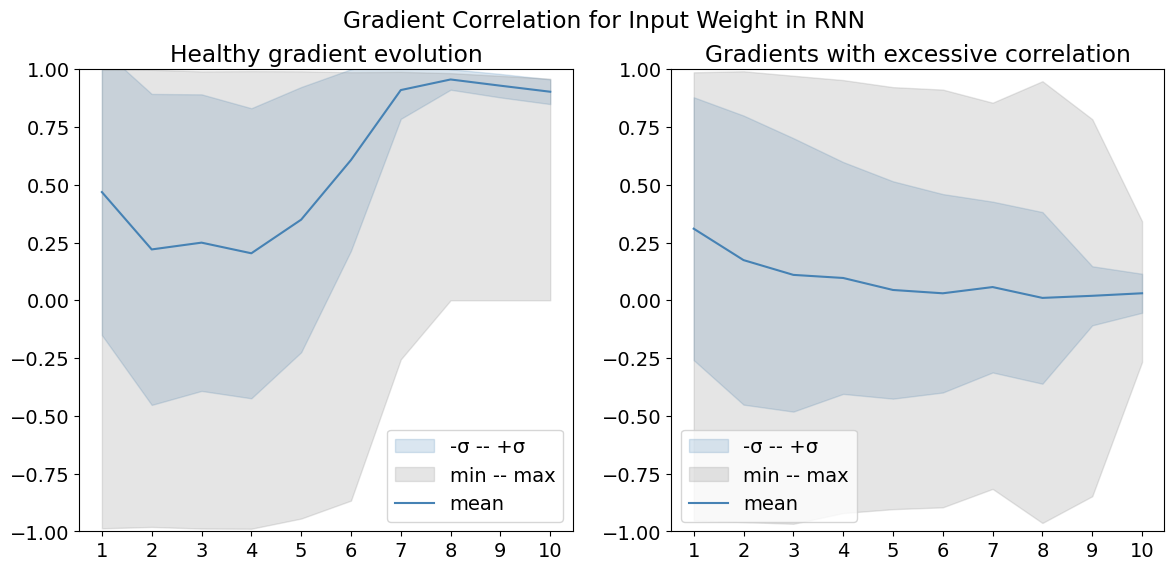

In [6]:
fig, [ax1, ax2] = plt.subplots(ncols=2, figsize=(14,6))
fig.suptitle('Gradient Correlation for Input Weight in RNN')

ax1.set_title('Healthy gradient evolution')
vals, ranges = good_to_plot['Weight_Ih_L0 Gradient Correlation']['rnn']
MatplotlibVisualizer._plot_numerical(ax1, vals, ranges)
ax1.legend()
ax1.set_ylim(-1, 1)

ax2.set_title('Gradients with excessive correlation')
vals, ranges = bad_to_plot['Weight_Ih_L0 Gradient Correlation']['rnn']
MatplotlibVisualizer._plot_numerical(ax2, vals, ranges)
ax2.legend()
ax2.set_ylim(-1, 1)

fig.savefig('figs/gradient_correlation_comparison.pdf')